# Task Using KNN, Logistic Regression and Naive Bayes

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv("employee_turnover.csv")
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [ ]:
df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

<Axes: >

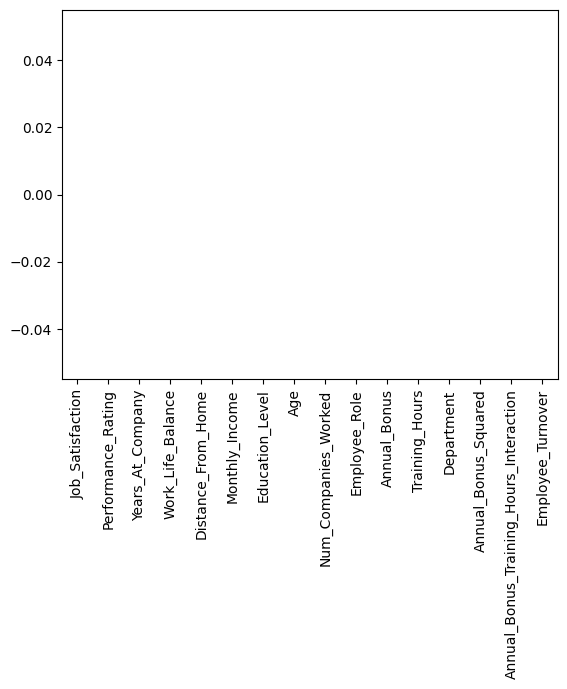

In [ ]:
df.isnull().sum().plot(kind="bar")

In [ ]:
df["Employee_Turnover"].unique()

array([0, 1], dtype=int64)

# Using KNN First

In [ ]:
X = df.drop("Employee_Turnover", axis=1)
y = df["Employee_Turnover"]

In [ ]:
X.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000


In [ ]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Employee_Turnover, dtype: int64

In [ ]:
classifier = KNeighborsClassifier()
param_grid = {"n_neighbors": [3, 5, 7, 9]}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeLine = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

param_grid = {"knn__n_neighbors": [3, 5, 7, 9]} # __ heirachial separation

#KNN classifier and inside that we are doing CV
knnCV = GridSearchCV(
    pipeLine, param_grid, cv=5)


knnCV.fit(X_train, y_train)

y_pred = knnCV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Best K paramter:", knnCV.best_params_)

Accuracy: 0.7888888888888889
Precision Score: 0.7833333333333333
Recall: 0.752
Best K paramter: {'knn__n_neighbors': 9}


# Using Logistic Regression 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2']
}

logregCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5
)

logregCV.fit(X_train, y_train)

y_pred = logregCV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Best Parameters:", logregCV.best_params_)

Accuracy: 0.8592592592592593
Precision: 0.8717948717948718
Recall: 0.816
Best Parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l2'}


# Using Naive Bayes

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

param_grid = {
    'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

nbCV = GridSearchCV(
    pipeline,
    param_grid,
    cv=5
)

nbCV.fit(X_train, y_train)

y_pred = nbCV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Best Parameters:", nbCV.best_params_)

Accuracy: 0.8333333333333334
Precision: 0.8278688524590164
Recall: 0.808
Best Parameters: {'nb__var_smoothing': 1e-09}


In [ ]:
models = {'Logistic Regression': logregCV, 'KNN': knnCV, 'Naive Bayes': nbCV}

for name, model in models.items():
    y_pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, y_pred))
    
    print("cm:", confusion_matrix(y, y_pred))

    print("classification report:", classification_report(y, y_pred))


Logistic Regression
Accuracy: 0.8622222222222222
cm: [[591  87]
 [ 99 573]]
classification report:               precision    recall  f1-score   support

           0       0.86      0.87      0.86       678
           1       0.87      0.85      0.86       672

    accuracy                           0.86      1350
   macro avg       0.86      0.86      0.86      1350
weighted avg       0.86      0.86      0.86      1350


KNN
Accuracy: 0.8355555555555556
cm: [[585  93]
 [129 543]]
classification report:               precision    recall  f1-score   support

           0       0.82      0.86      0.84       678
           1       0.85      0.81      0.83       672

    accuracy                           0.84      1350
   macro avg       0.84      0.84      0.84      1350
weighted avg       0.84      0.84      0.84      1350


Naive Bayes
Accuracy: 0.8466666666666667
cm: [[579  99]
 [108 564]]
classification report:               precision    recall  f1-score   support

           0   

In [ ]:
# Best Algo to use in this case is Logistic regression 

# More easy way

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X = df.drop("Employee_Turnover", axis=1)
y = df["Employee_Turnover"]

classifier = KNeighborsClassifier()
param_grid = {"n_neighbors": [3, 5, 7, 9]}

#KNN classifier and inside that we are doing CV
classifierCV = GridSearchCV(
    classifier, param_grid, cv=5)


classifierCV.fit(X_train_scaled, y_train)

y_pred = classifierCV.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Best K paramter:", classifierCV.best_params_)

Accuracy: 0.7888888888888889
Precision Score: 0.7833333333333333
Recall: 0.752
Best K paramter: {'n_neighbors': 9}


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0], dtype=int64)

In [ ]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy:  0.8592592592592593
Precision Score: 0.8717948717948718
Recall: 0.816


In [ ]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

y_pred = gnb_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy:  0.8333333333333334
Precision Score: 0.8278688524590164
Recall: 0.808
